 ## Imports

In [1]:
import os
import glob
import random
from zipfile import Path
import numpy as np                                  # For numerical operations
import matplotlib.pyplot as plt                     # For plotting
from PIL import Image                               # For image processing
from skimage.color import rgb2lab, lab2rgb          # Provides RGB <-> Lab conversion.
import torch
import torch.nn as nn                               # For building neural networks
import torch.nn.functional as F                     # For activation functions and other utilities
import torch.optim as optim                         # For optimization algorithms
from torch.utils.data import Dataset, DataLoader    # For handling datasets and batching
import torchvision                                  # Useful for image grids

 ## Experiment settings

In [2]:
data_root = "C:/Cloud/OneDrive - Université Libre de Bruxelles/1 - School/ULB/Master/MA2/2025-26 - Q2/ELEC-Y591 - Machine Learning And Big Data Processes/ELEC-Y591 - Project Workspace/data"
image_size = 32
batch_size = 8
num_epochs = 10
warmup_epochs = 2           # Generator warm-up epochs (L1 only before adversarial training)
lambda_l1 = 100.0           # L1 weight (pix2pix-style colorization)
lr = 2e-4                   # Learning rate
beta1 = 0.5                 # Adam beta1
device = "cuda:0"           # Device to use for training
num_workers = 0
pin_memory = str(device).startswith("cuda")

 ## Lab Conversion Helpers

In [3]:
def rgb_to_lab_transform(pil_img):
    """
    Transform function that converts a PIL RGB image into normalized L and lab tensors.

    Output:
        L_tensor:   [1, H, W], values roughly in [-1, 1]
        lab_tensor: [3, H, W], values roughly in [-1, 1]
    """
    # Handle grayscale or RGBA images
    pil_img = pil_img.convert("RGB")

    # Convert PIL image to NumPy array in [0, 1].
    rgb = np.asarray(pil_img).astype(np.float32) / 255.0

    # Convert RGB to Lab.
    lab = rgb2lab(rgb).astype(np.float32)

    # Split L channel for condition.
    L = lab[:, :, 0:1]

    # Normalize. L is [0, 100], ab is [-128, 127]
    L_norm = (L / 50.0) - 1.0
    ab_norm = lab[:, :, 1:3] / 128.0
    lab_norm = np.concatenate([L_norm, ab_norm], axis=2)

    # Convert HWC -> CHW for PyTorch.
    L_norm = np.transpose(L_norm, (2, 0, 1))
    lab_norm = np.transpose(lab_norm, (2, 0, 1))

    # Convert NumPy arrays to PyTorch tensors.
    L_tensor = torch.from_numpy(L_norm).float()
    lab_tensor = torch.from_numpy(lab_norm).float()

    return L_tensor, lab_tensor


def lab_tensors_to_rgb(L_tensor, lab_tensor):
    """
    Convert normalized lab tensor back to an RGB NumPy image.

    Input:
        L_tensor:   [1, H, W] or [B, 1, H, W] (Unused here, kept for API compatibility)
        lab_tensor: [3, H, W] or [B, 3, H, W]

    Output:
        RGB NumPy image or batch in [0, 1].
    """
    lab = lab_tensor.detach().cpu()

    # If input is a single image, add batch dimension temporarily.
    single = False
    if lab.ndim == 3:
        lab = lab.unsqueeze(0)
        single = True

    # Convert from normalized range back to Lab range.
    L_unnorm = (lab[:, 0:1, :, :] + 1.0) * 50.0
    ab_unnorm = lab[:, 1:3, :, :] * 128.0

    lab = torch.cat([L_unnorm, ab_unnorm], dim=1)
    lab = lab.permute(0, 2, 3, 1).numpy()

    rgb_images = []
    for lab_img in lab:
        # lab2rgb returns values in [0, 1].
        rgb = lab2rgb(lab_img).astype(np.float32)
        rgb_images.append(rgb)

    rgb_images = np.stack(rgb_images, axis=0)

    if single:
        return rgb_images[0]

    return rgb_images


def show_rgb_image(rgb, title=None):
    """
    Display one RGB image represented as a NumPy array in [0, 1].
    """
    rgb = np.clip(rgb, 0.0, 1.0)
    plt.figure(figsize=(4, 4))
    plt.imshow(rgb)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

 ## Build the Colorization Dataset

In [4]:
class LabColorizationDataset(Dataset):
    """
    Generic wrapper for grayscale-to-color training.

    Many torchvision datasets return:
        image, class_label

    The base CIFAR-10 dataset returns:
        (L, ab), class_label

    This wrapper ignores the class label and returns:
        L:  [1, H, W]
        lab: [3, H, W]
    """
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        # The base dataset returns ((L, lab), label) because of the transform.
        # Discard the label, we only need the images for colorization.
        (L, lab), _ = self.base_dataset[index]
        return L, lab

 ## Create DataLoaders

In [5]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((image_size, image_size)),
    # torchvision.transforms.RandomHorizontalFlip(p=0.5), # This increases the dataset without needing for more samples. I don't think we will need it for now anyways
    rgb_to_lab_transform,
])

val_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((image_size, image_size)),
    rgb_to_lab_transform,
])


# Base datasets
cifar_train_base = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=train_transform,
)

cifar_val_base = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=False,
    transform=val_transform,
)

# Wrapper to discard CIFAR-10 labels
trainset = LabColorizationDataset(
    base_dataset=cifar_train_base,
)

valset = LabColorizationDataset(
    base_dataset=cifar_val_base,
)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

valloader = DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

print(f"Training images: {len(trainset)}")
print(f"Validation images: {len(valset)}")
print(f"DataLoader workers: {num_workers}")
print(f"Device: {device}")

L_batch, lab_batch = next(iter(trainloader))
print(L_batch.shape)
print(lab_batch.shape)
print(L_batch.min().item(), L_batch.max().item())
print(lab_batch.min().item(), lab_batch.max().item())

c:\Users\sipak\anaconda3\envs\ml_project\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training images: 50000
Validation images: 10000
DataLoader workers: 0
Device: cuda:0
torch.Size([8, 1, 32, 32])
torch.Size([8, 3, 32, 32])
-1.0 1.0
-1.0 1.0


 ## Inspect One Batch

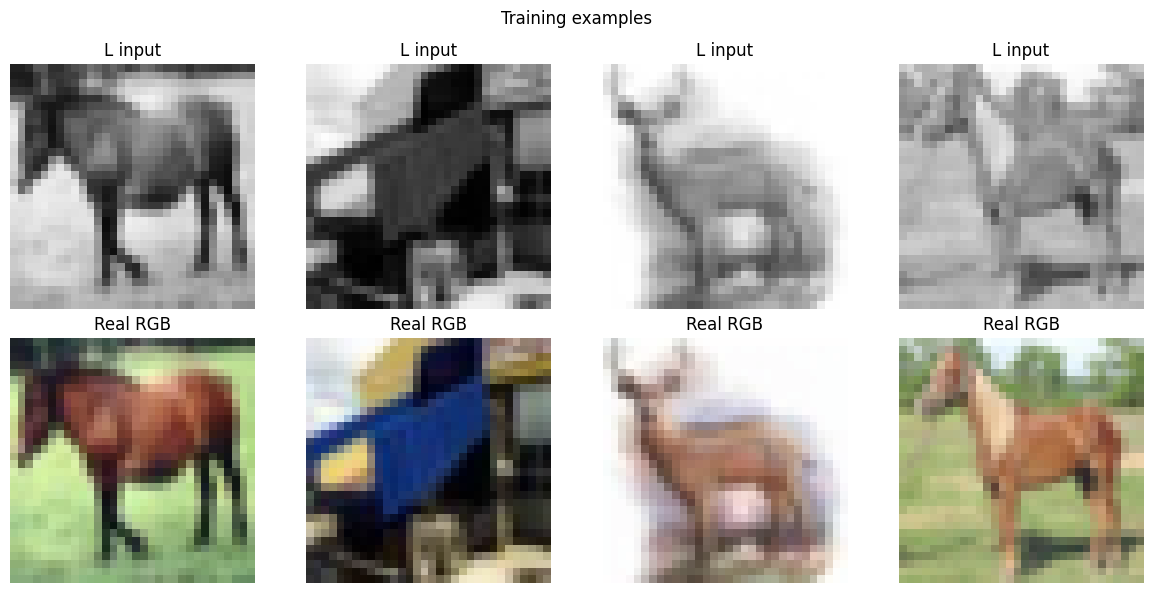

In [6]:
def show_colorization_batch(L_batch, lab_batch, max_images=4, title="Batch"):
    """
    Show L grayscale inputs and RGB images reconstructed from real ab.
    """
    L_batch = L_batch[:max_images]
    lab_batch = lab_batch[:max_images]

    rgb_batch = lab_tensors_to_rgb(L_batch, lab_batch)

    n = len(rgb_batch)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))

    if n == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(n):
        # Show L channel as grayscale.
        L_img = L_batch[i, 0].detach().cpu().numpy()
        L_img = (L_img + 1.0) / 2.0

        axes[0, i].imshow(L_img, cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[0, i].set_title("L input")

        axes[1, i].imshow(np.clip(rgb_batch[i], 0, 1))
        axes[1, i].axis("off")
        axes[1, i].set_title("Real RGB")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


L_batch, lab_batch = next(iter(trainloader))
show_colorization_batch(L_batch, lab_batch, max_images=4, title="Training examples")

 ## Build the U-Net Generator

In [7]:
class UNetGenerator(nn.Module):
    """
    U-Net generator matching the reference paper 1803.05400v5.pdf.

    Input:
        L image [B, 1, 32, 32]

    Output:
        predicted Lab [B, 3, 32, 32]
    """
    def __init__(self, input_channels=1, output_channels=3):
        super().__init__()

        # Encoder: Series of 4x4 convs with stride 2
        self.conv0 = nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1)       # 32 -> 16
        self.conv1 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)                  # 16 -> 8
        self.conv2 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)                 # 8 -> 4
        self.conv3 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)                 # 4 -> 2
        self.conv4 = nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1)                 # 2 -> 1

        # Batch normalization after encoder layers (except first)
        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(512)
        self.bn4 = nn.BatchNorm2d(512)

        # Decoder: Mirrored transposed-convolution layers
        self.deconv0 = nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1)      # 1 -> 2
        self.deconv1 = nn.ConvTranspose2d(1024, 256, kernel_size=4, stride=2, padding=1)     # 2 -> 4
        self.deconv2 = nn.ConvTranspose2d(512, 128, kernel_size=4, stride=2, padding=1)      # 4 -> 8
        self.deconv3 = nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1)       # 8 -> 16
        self.deconv4 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)       # 16 -> 32

        # Batch normalization in the decoder after skip concatenation
        self.dbn0 = nn.BatchNorm2d(1024)
        self.dbn1 = nn.BatchNorm2d(512)
        self.dbn2 = nn.BatchNorm2d(256)
        self.dbn3 = nn.BatchNorm2d(128)
        self.dbn4 = nn.BatchNorm2d(64)

        # Final layer: 1x1 convolution
        self.final_conv = nn.Conv2d(64, output_channels, kernel_size=1, stride=1, padding=0) # 32 -> 32

    def forward(self, x):
        # Encoder
        e0 = F.leaky_relu(self.conv0(x), negative_slope=0.2)              # [B, 64, 16, 16]
        e1 = F.leaky_relu(self.bn1(self.conv1(e0)), negative_slope=0.2)   # [B, 128, 8, 8]
        e2 = F.leaky_relu(self.bn2(self.conv2(e1)), negative_slope=0.2)   # [B, 256, 4, 4]
        e3 = F.leaky_relu(self.bn3(self.conv3(e2)), negative_slope=0.2)   # [B, 512, 2, 2]
        e4 = F.leaky_relu(self.bn4(self.conv4(e3)), negative_slope=0.2)   # [B, 512, 1, 1]

        # Decoder
        d0 = self.deconv0(e4)                                              # [B, 512, 2, 2]
        d0 = torch.cat([d0, e3], dim=1)                                    # [B, 1024, 2, 2]
        d0 = F.relu(self.dbn0(d0))
        d0 = F.dropout(d0, p=0.5, training=self.training)

        d1 = self.deconv1(d0)                                              # [B, 256, 4, 4]
        d1 = torch.cat([d1, e2], dim=1)                                    # [B, 512, 4, 4]
        d1 = F.relu(self.dbn1(d1))
        d1 = F.dropout(d1, p=0.5, training=self.training)

        d2 = self.deconv2(d1)                                              # [B, 128, 8, 8]
        d2 = torch.cat([d2, e1], dim=1)                                    # [B, 256, 8, 8]
        d2 = F.relu(self.dbn2(d2))

        d3 = self.deconv3(d2)                                              # [B, 64, 16, 16]
        d3 = torch.cat([d3, e0], dim=1)                                    # [B, 128, 16, 16]
        d3 = F.relu(self.dbn3(d3))
        
        d4 = self.deconv4(d3)                                              # [B, 64, 32, 32]
        d4 = F.relu(self.dbn4(d4))

        # Final 1x1 convolution predicts normalized Lab values in [-1, 1].
        out = torch.tanh(self.final_conv(d4))                              # [B, 3, 32, 32]
        return out

G = UNetGenerator(input_channels=1, output_channels=3).to(device)

L_batch, lab_batch = next(iter(trainloader))
with torch.no_grad():
    fake_lab = G(L_batch.to(device))

print(fake_lab.shape)

torch.Size([8, 3, 32, 32])


 ## Build the Conditional Discriminator

In [8]:
class ConditionalDiscriminator(nn.Module):
    """
    Conditional convolutional discriminator matching paper 1803.05400v5.pdf.

    Input:
        concat(L, lab) with shape [B, 4, 32, 32]

    Output:
        raw real/fake logits [B, 1, 1, 1]
    """
    def __init__(self, input_channels=4):
        super().__init__()

        # The discriminator is a series of 4x4 convs with stride 2.
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1)       # 32 -> 16
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)                  # 16 -> 8
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)                 # 8 -> 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)                 # 4 -> 2

        # Final layer maps the remaining 2x2 feature map to one raw logit.
        self.conv5 = nn.Conv2d(512, 1, kernel_size=2, stride=1, padding=0)                   # 2 -> 1

        # Batch normalization except after the first layer.
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), negative_slope=0.2)

        # Raw real/fake logits.
        x = self.conv5(x)
        return x

D = ConditionalDiscriminator(input_channels=4).to(device)

L_batch, lab_batch = next(iter(trainloader))
pair = torch.cat([L_batch, lab_batch], dim=1).to(device)

with torch.no_grad():
    logits = D(pair)

print(pair.shape)
print(logits.shape)

torch.Size([8, 4, 32, 32])
torch.Size([8, 1, 1, 1])


 ## Add Helpers

In [9]:
def count_parameters(model):
    """
    Count trainable parameters in a PyTorch model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def set_requires_grad(model, requires_grad):
    """
    Turn gradients on or off for a model.

    Useful because:
        - when training D, G should not update from D loss
        - when training G, D is used for gradients but D optimizer should not step
    """
    for p in model.parameters():
        p.requires_grad = requires_grad


def make_labels_like(logits, value):
    """
    Create a label tensor with the same shape as discriminator logits.

    value = 1.0 for real
    value = 0.0 for fake
    value = 0.9 for smoothed real labels
    """
    return torch.full_like(logits, fill_value=value, device=logits.device)


def visualize_predictions(generator, dataloader, device, max_images=4, title="Colorization"):
    """
    Show:
        L grayscale | ground truth RGB | generated RGB
    """
    generator.eval()

    L_batch, lab_batch = next(iter(dataloader))
    L_batch = L_batch[:max_images].to(device)
    lab_batch = lab_batch[:max_images].to(device)

    with torch.no_grad():
        fake_lab = generator(L_batch)

    real_rgb = lab_tensors_to_rgb(L_batch, lab_batch)
    fake_rgb = lab_tensors_to_rgb(L_batch, fake_lab)

    n = L_batch.shape[0]
    fig, axes = plt.subplots(3, n, figsize=(3 * n, 9))

    if n == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(n):
        L_img = L_batch[i, 0].detach().cpu().numpy()
        L_img = (L_img + 1.0) / 2.0

        axes[0, i].imshow(L_img, cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[0, i].set_title("L")

        axes[1, i].imshow(np.clip(real_rgb[i], 0, 1))
        axes[1, i].axis("off")
        axes[1, i].set_title("Real RGB")

        axes[2, i].imshow(np.clip(fake_rgb[i], 0, 1))
        axes[2, i].axis("off")
        axes[2, i].set_title("Generated RGB")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    generator.train()

 ## Train Generator With L1 Only

Generator parameters: 16,787,715
Warm-up epoch 1/2 | L1 loss: 0.0617


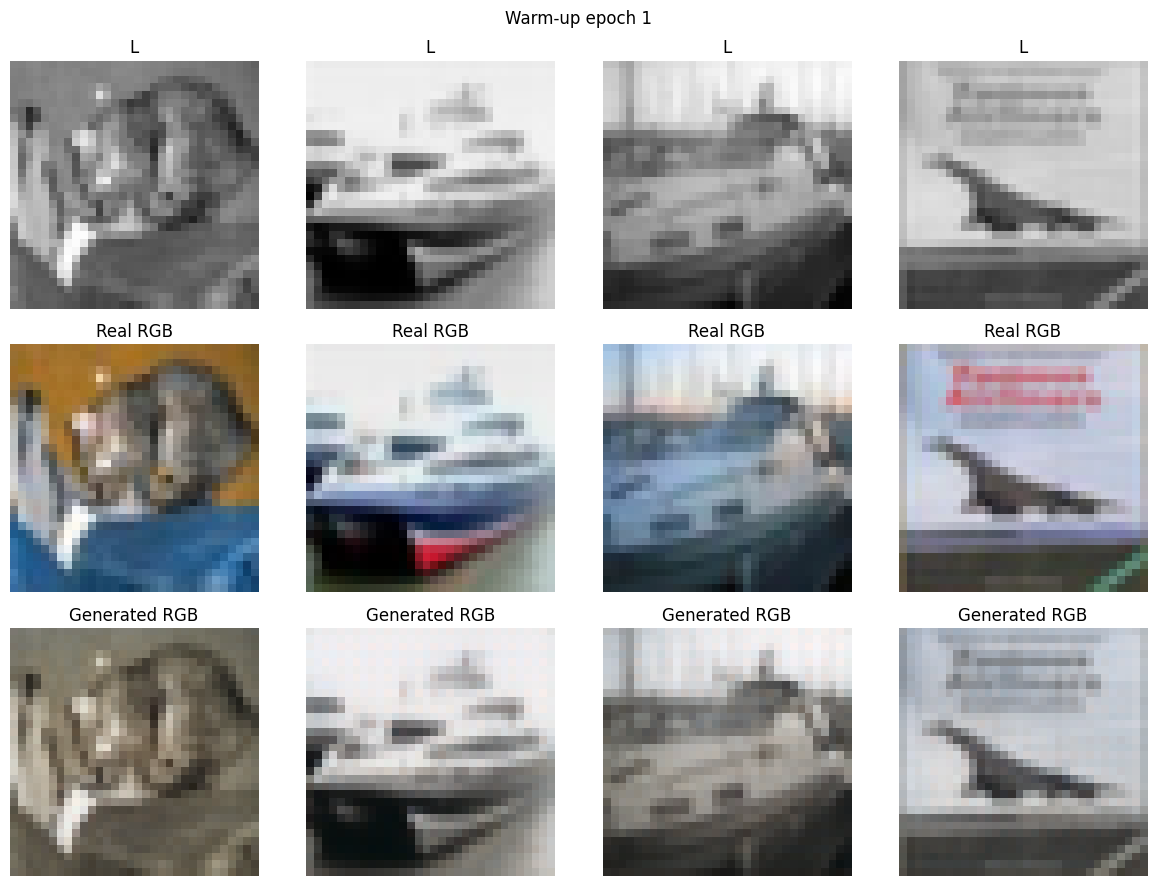

Warm-up epoch 2/2 | L1 loss: 0.0521


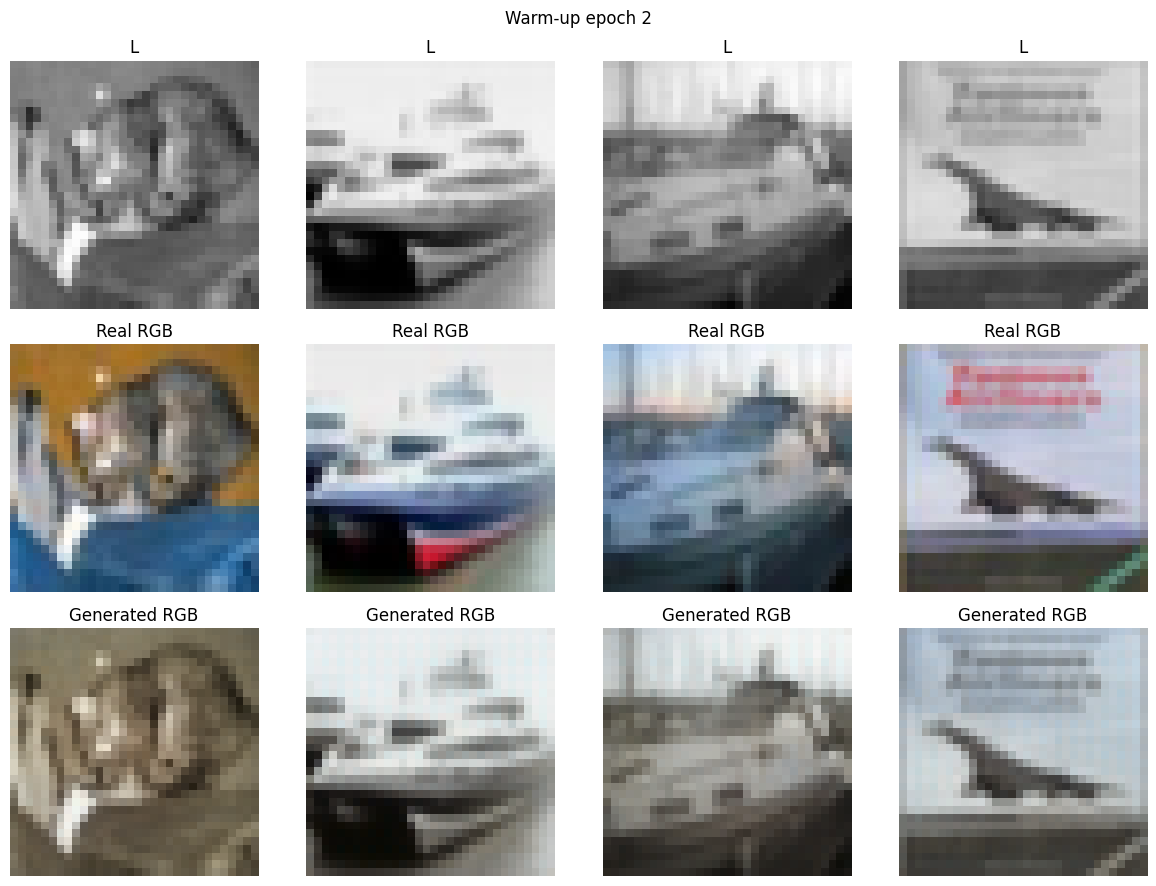

In [10]:
G = UNetGenerator(input_channels=1, output_channels=3).to(device)

print(f"Generator parameters: {count_parameters(G):,}")

# L1 loss is standard for pix2pix-style image translation.
criterion_l1 = nn.L1Loss()

# Adam optimizer for generator.
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))


def train_generator_l1_one_epoch(generator, dataloader, optimizer, criterion, device):
    """
    Train generator for one epoch using only L1 reconstruction loss.
    """
    generator.train()
    running_loss = 0.0

    for L_batch, lab_batch in dataloader:
        L_batch = L_batch.to(device)
        lab_batch = lab_batch.to(device)

        # Forward pass: predict color channels from L.
        fake_lab = generator(L_batch)

        # Reconstruction loss.
        loss = criterion(fake_lab, lab_batch)

        # Standard PyTorch training step.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * L_batch.size(0)

    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss


for epoch in range(warmup_epochs):
    train_loss = train_generator_l1_one_epoch(
        generator=G,
        dataloader=trainloader,
        optimizer=optimizer_G,
        criterion=criterion_l1,
        device=device,
    )

    print(f"Warm-up epoch {epoch + 1}/{warmup_epochs} | L1 loss: {train_loss:.4f}")
    visualize_predictions(G, valloader, device, max_images=4, title=f"Warm-up epoch {epoch + 1}")

 ## Create Discriminator, Losses, Optimizers
 Create discriminator.

In [11]:
D = ConditionalDiscriminator(input_channels=4).to(device)

print(f"Discriminator parameters: {count_parameters(D):,}")

# BCEWithLogitsLoss expects raw logits.
# Therefore ConditionalDiscriminator does not end with sigmoid.
criterion_gan = nn.BCEWithLogitsLoss()

# L1 criterion was already defined, but define again for clarity.
criterion_l1 = nn.L1Loss()

# Optimizers.
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))


L_batch, lab_batch = next(iter(trainloader))
L_batch = L_batch.to(device)
lab_batch = lab_batch.to(device)

with torch.no_grad():
    fake_lab = G(L_batch)
    real_pair = torch.cat([L_batch, lab_batch], dim=1)
    fake_pair = torch.cat([L_batch, fake_lab], dim=1)
    real_logits = D(real_pair)
    fake_logits = D(fake_pair)

print(real_logits.shape)
print(fake_logits.shape)

Discriminator parameters: 2,761,409
torch.Size([8, 1, 1, 1])
torch.Size([8, 1, 1, 1])


 ## Write One GAN Epoch

In [12]:
def train_gan_one_epoch(
    generator,
    discriminator,
    dataloader,
    optimizer_G,
    optimizer_D,
    criterion_gan,
    criterion_l1,
    lambda_l1,
    device,
    real_label_value=0.9,
):
    """
    Train GAN for one epoch.

    real_label_value=0.9 applies one-sided label smoothing,
    which is one of the stabilization techniques mentioned in the paper.
    """
    generator.train()
    discriminator.train()

    running_D = 0.0
    running_G = 0.0
    running_G_gan = 0.0
    running_G_l1 = 0.0

    for L_batch, lab_batch in dataloader:
        L_batch = L_batch.to(device)
        lab_batch = lab_batch.to(device)

        # ------------------------------------------------------------
        # 1. Train Discriminator
        # ------------------------------------------------------------

        set_requires_grad(discriminator, True)

        # Generate fake ab.
        fake_lab = generator(L_batch)

        # Real pair: L + real ab.
        real_pair = torch.cat([L_batch, lab_batch], dim=1)

        # Fake pair: L + generated ab.
        # detach() prevents gradients from updating G during D step.
        fake_pair = torch.cat([L_batch, fake_lab.detach()], dim=1)

        # Discriminator predictions.
        real_logits = discriminator(real_pair)
        fake_logits = discriminator(fake_pair)

        # Labels must match discriminator output shape.
        real_labels = make_labels_like(real_logits, real_label_value)
        fake_labels = make_labels_like(fake_logits, 0.0)

        # D should classify real as real and fake as fake.
        loss_D_real = criterion_gan(real_logits, real_labels)
        loss_D_fake = criterion_gan(fake_logits, fake_labels)
        loss_D = 0.5 * (loss_D_real + loss_D_fake)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ------------------------------------------------------------
        # 2. Train Generator
        # ------------------------------------------------------------

        # Freeze D parameters while updating G.
        # Gradients still flow through D's operations into G,
        # but D's own parameters are not updated by optimizer_G.
        set_requires_grad(discriminator, False)

        fake_lab = generator(L_batch)
        fake_pair = torch.cat([L_batch, fake_lab], dim=1)
        fake_logits_for_G = discriminator(fake_pair)

        # Generator wants fake pair to be classified as real.
        real_labels_for_G = make_labels_like(fake_logits_for_G, 1.0)
        loss_G_gan = criterion_gan(fake_logits_for_G, real_labels_for_G)

        # Generator also needs to match ground-truth ab.
        loss_G_l1 = criterion_l1(fake_lab, lab_batch)

        # Total generator loss.
        loss_G = loss_G_gan + lambda_l1 * loss_G_l1

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # Restore D gradients for next iteration.
        set_requires_grad(discriminator, True)

        batch_size_current = L_batch.size(0)
        running_D += loss_D.item() * batch_size_current
        running_G += loss_G.item() * batch_size_current
        running_G_gan += loss_G_gan.item() * batch_size_current
        running_G_l1 += loss_G_l1.item() * batch_size_current

    n = len(dataloader.dataset)

    return {
        "D": running_D / n,
        "G": running_G / n,
        "G_gan": running_G_gan / n,
        "G_l1": running_G_l1 / n,
    }

 ## Full Training Loop

Epoch 1/10 | D: 0.5828 | G: 7.5789 | G_gan: 1.3917 | G_l1: 0.0619


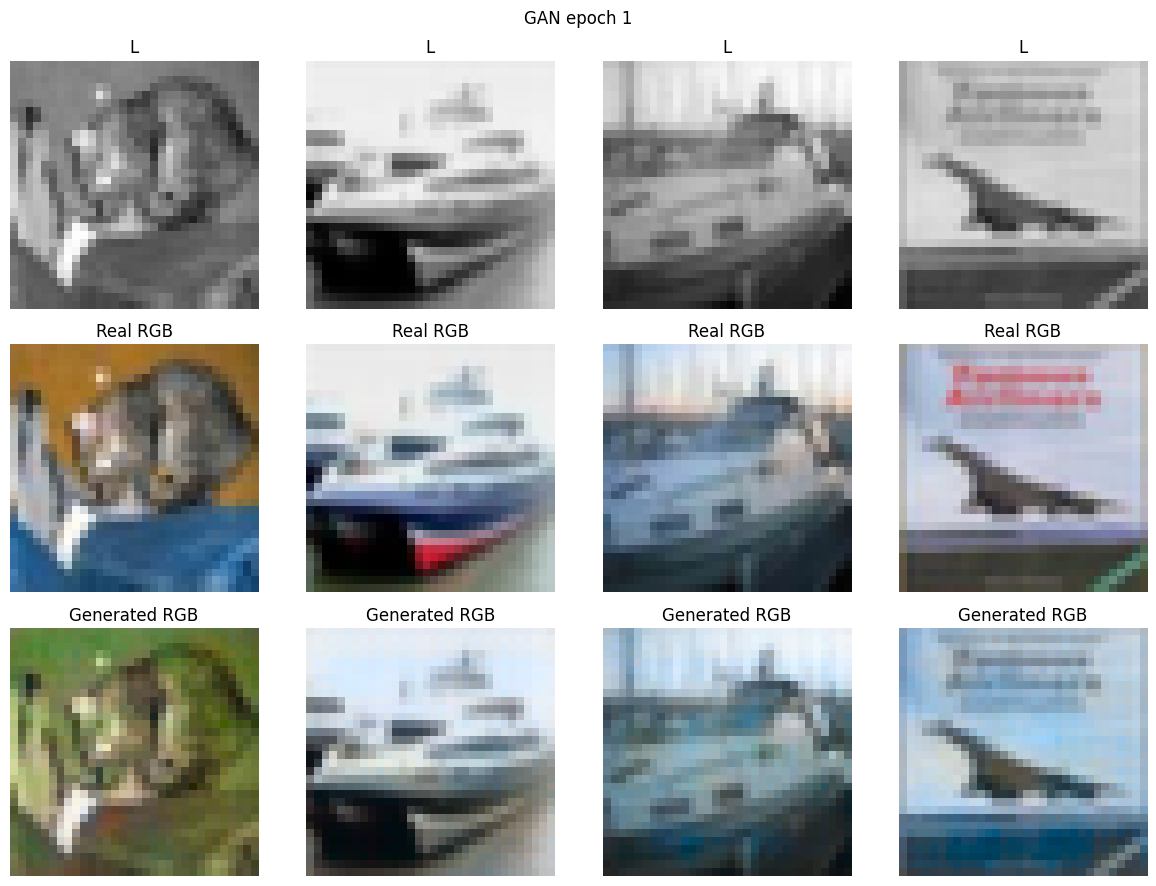

Epoch 2/10 | D: 0.5768 | G: 7.6571 | G_gan: 1.3778 | G_l1: 0.0628


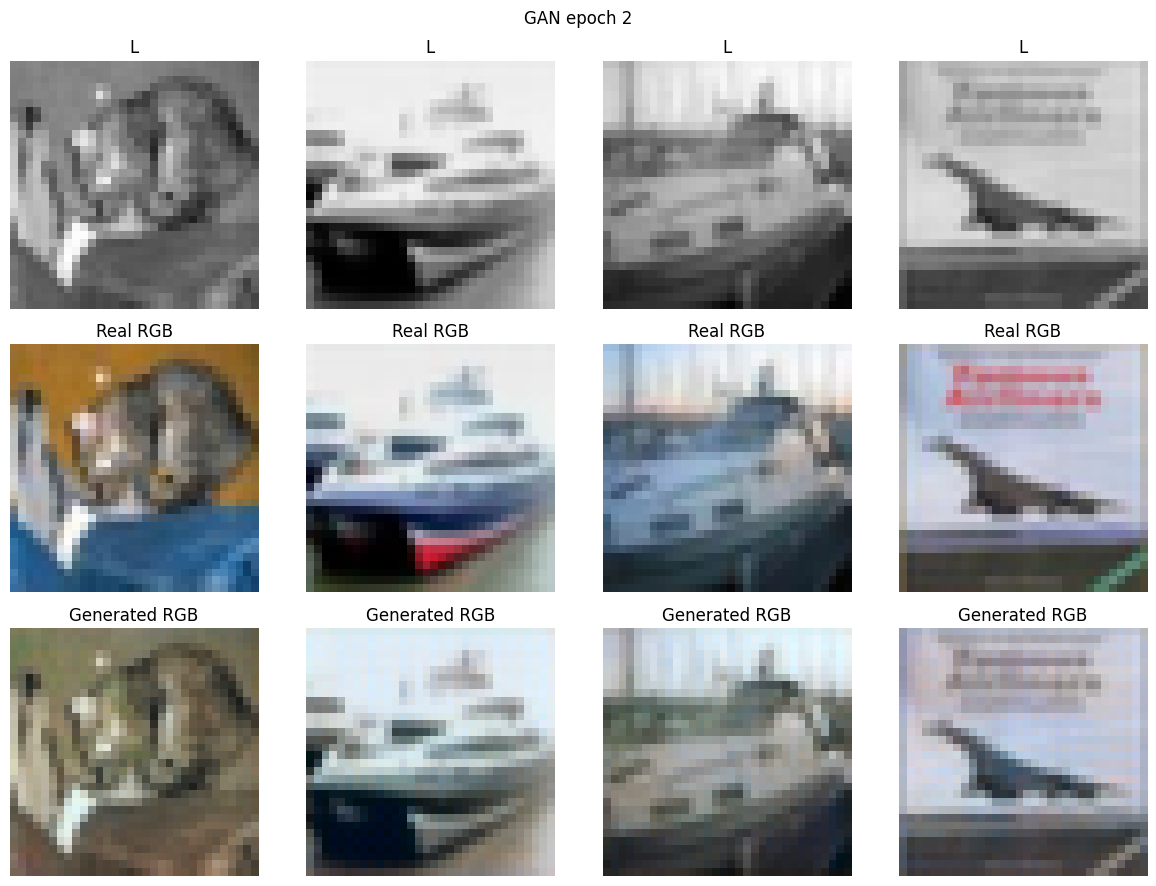

Epoch 3/10 | D: 0.5654 | G: 7.6817 | G_gan: 1.4343 | G_l1: 0.0625


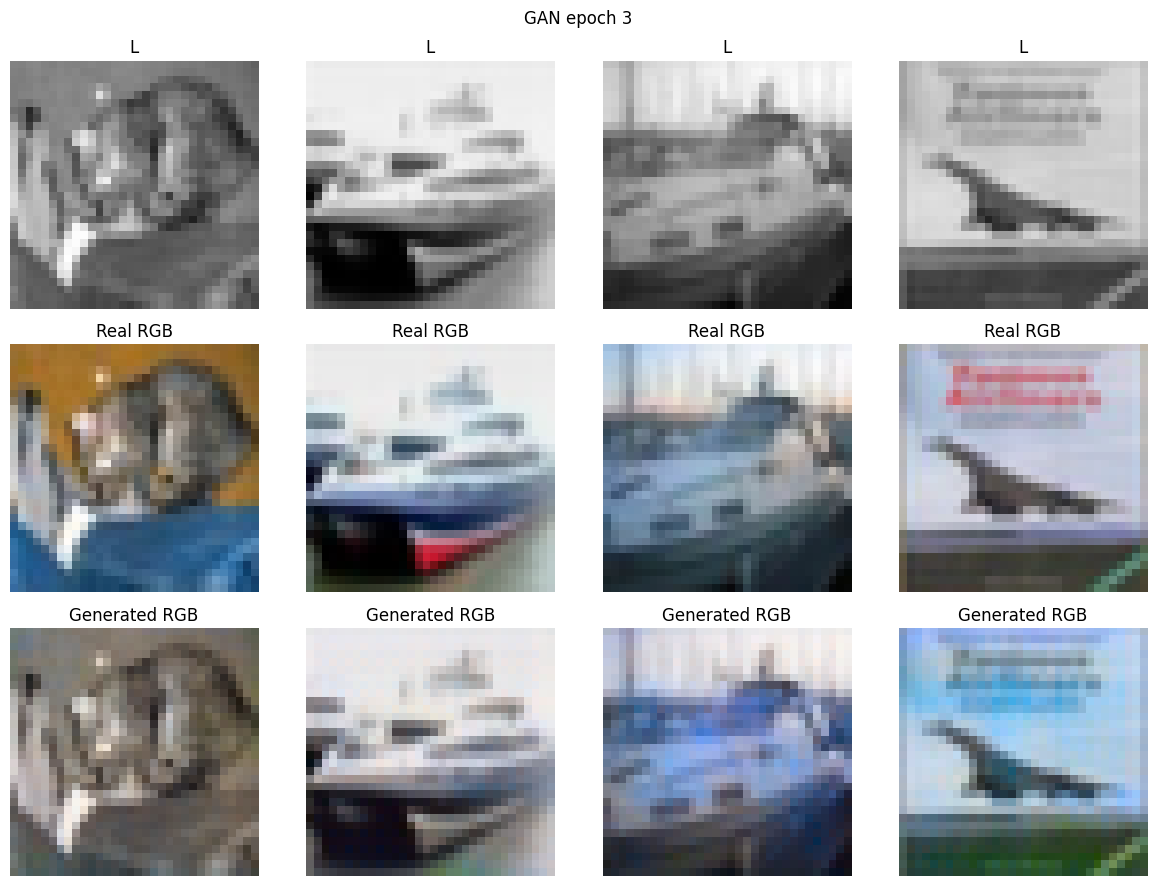

Epoch 4/10 | D: 0.5467 | G: 7.7550 | G_gan: 1.5259 | G_l1: 0.0623


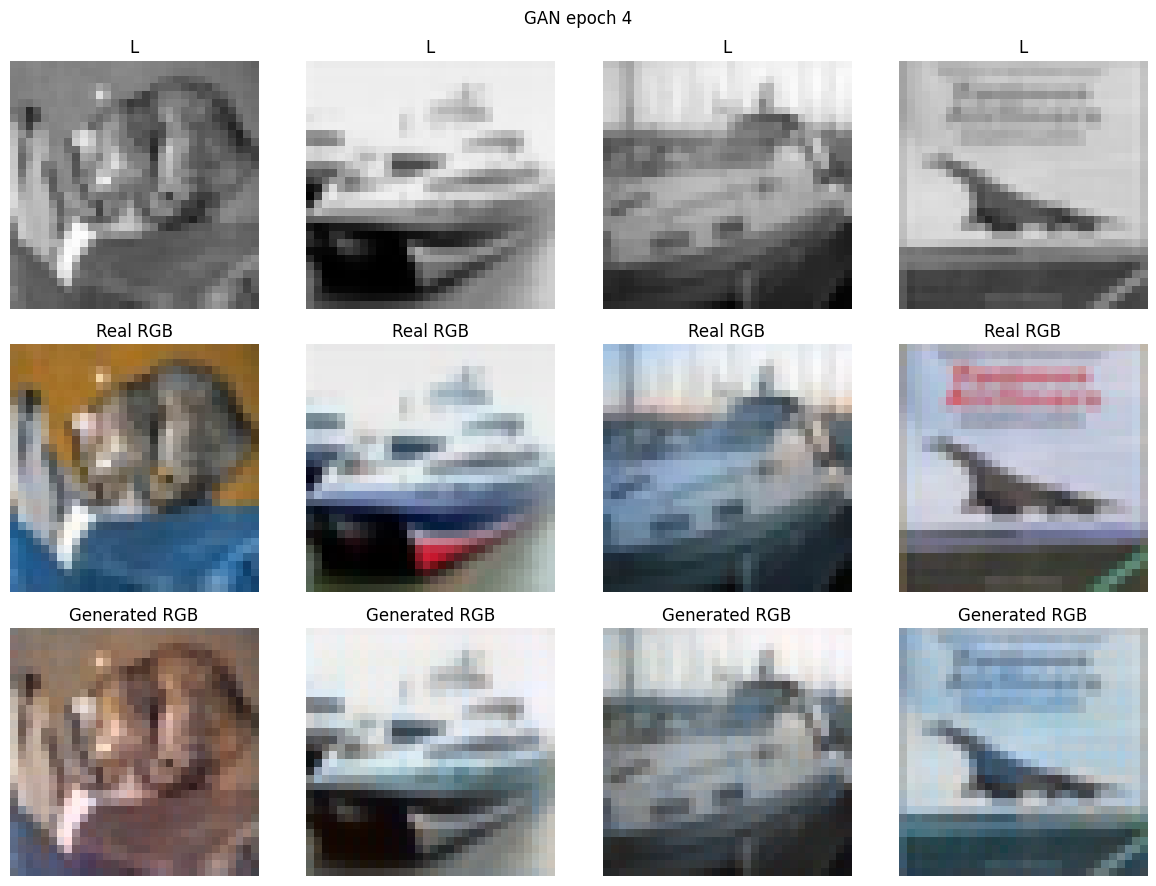

Epoch 5/10 | D: 0.5376 | G: 7.7926 | G_gan: 1.5795 | G_l1: 0.0621


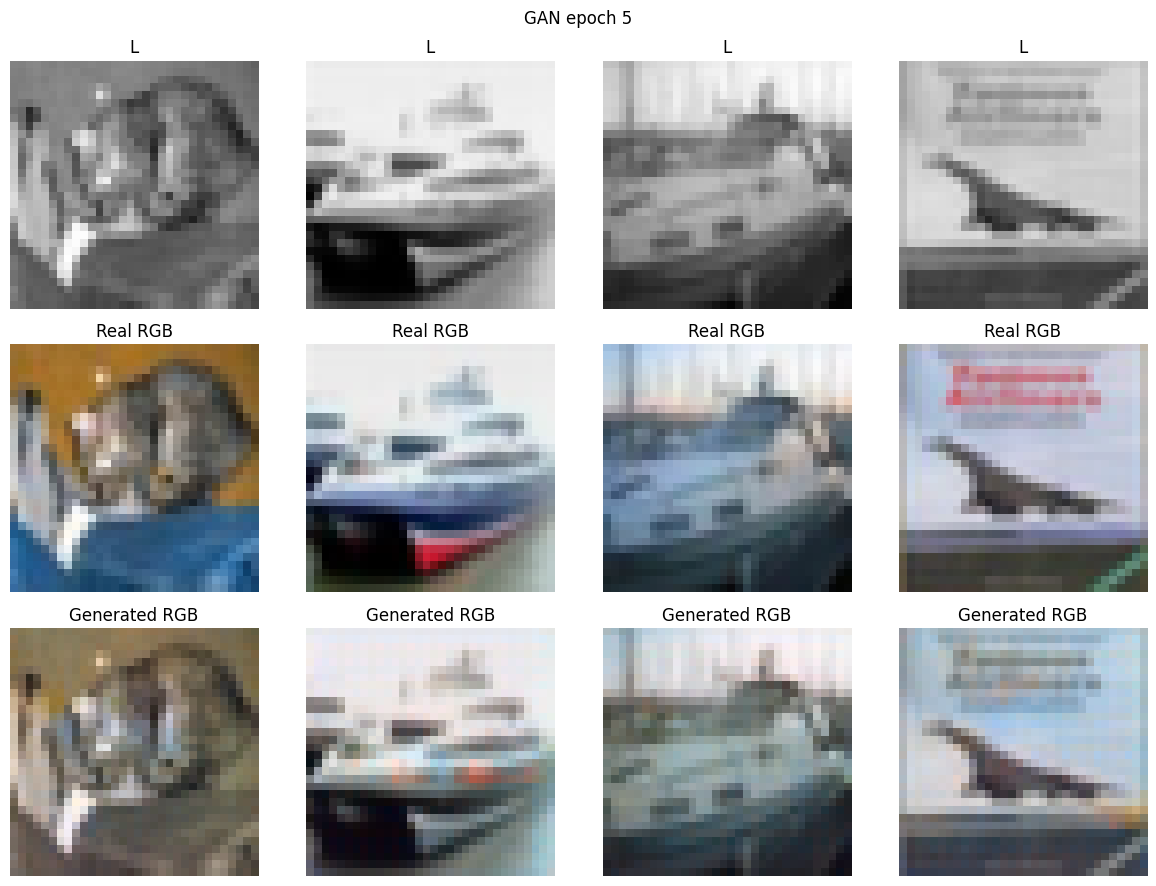

Epoch 6/10 | D: 0.5319 | G: 7.7679 | G_gan: 1.6025 | G_l1: 0.0617


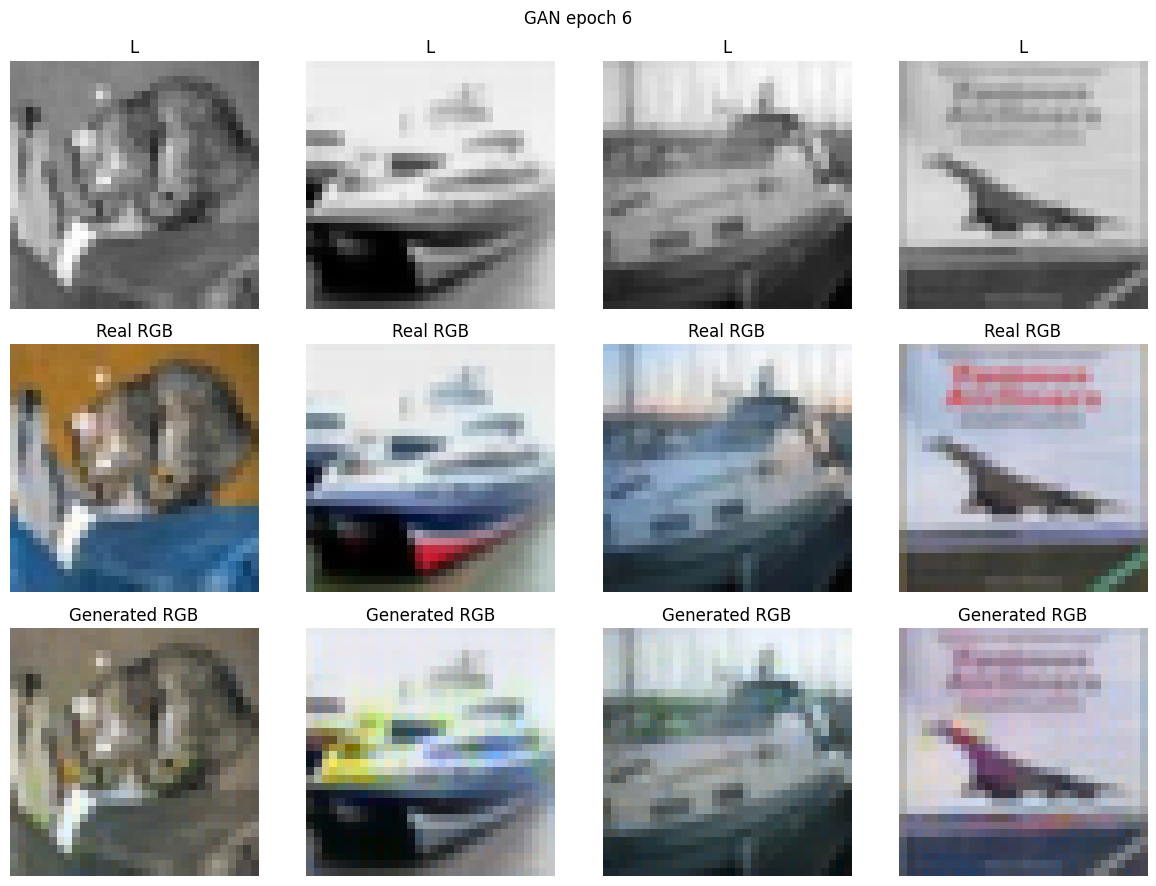

Epoch 7/10 | D: 0.5287 | G: 7.7627 | G_gan: 1.6276 | G_l1: 0.0614


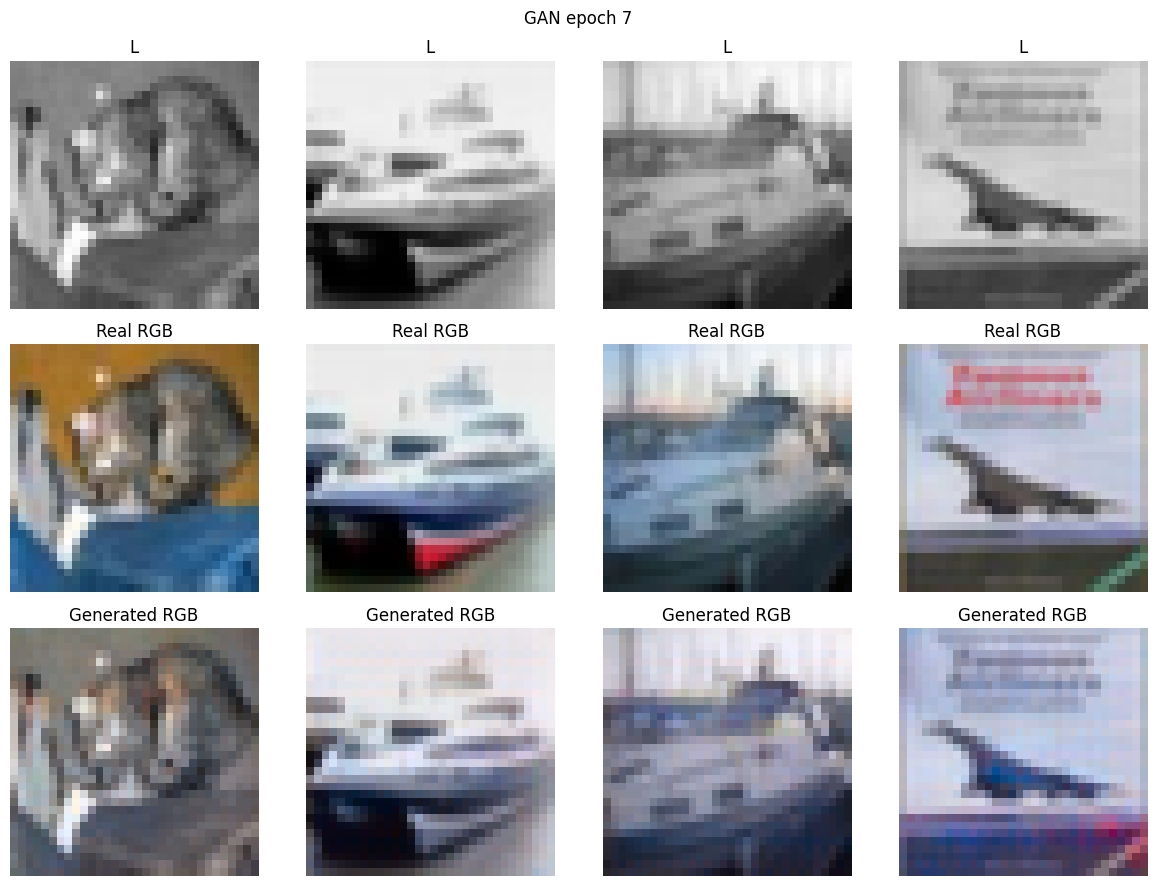

Epoch 8/10 | D: 0.5163 | G: 7.7817 | G_gan: 1.6821 | G_l1: 0.0610


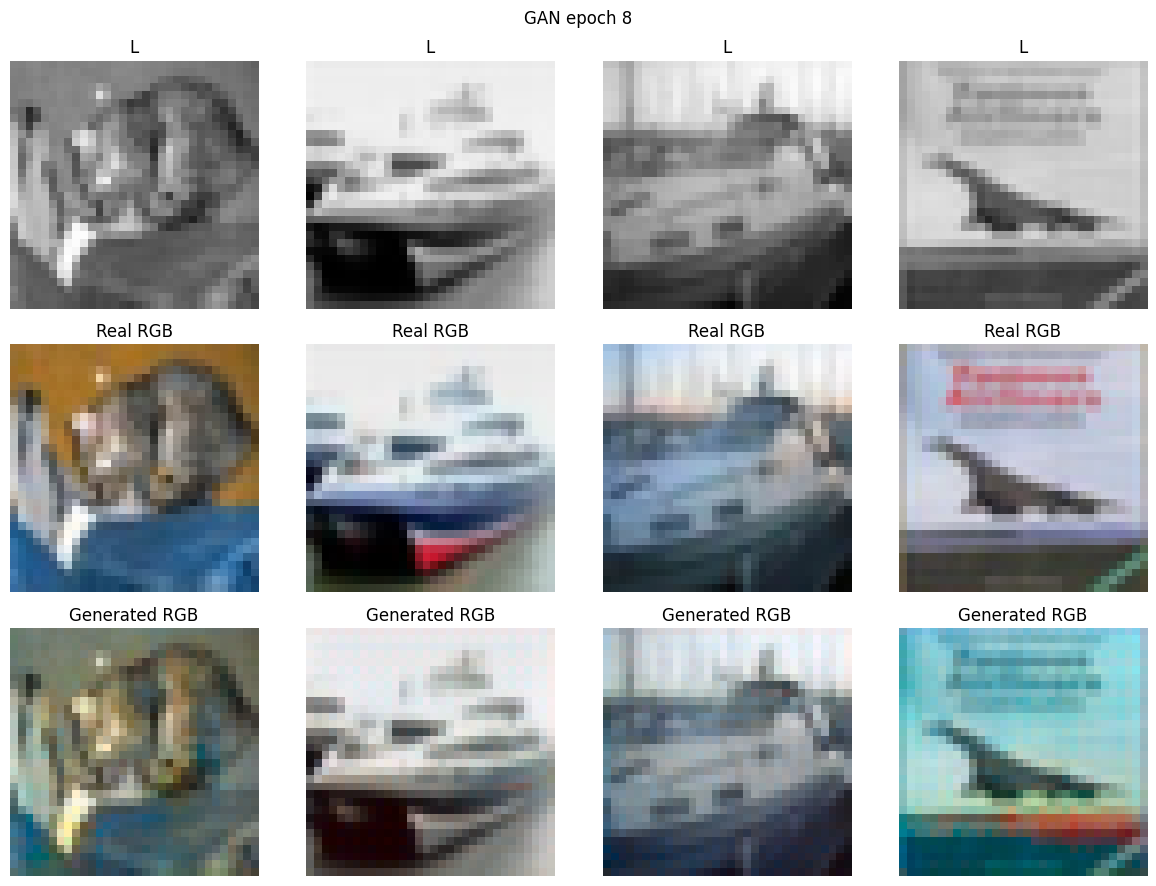

Epoch 9/10 | D: 0.5100 | G: 7.7770 | G_gan: 1.7262 | G_l1: 0.0605


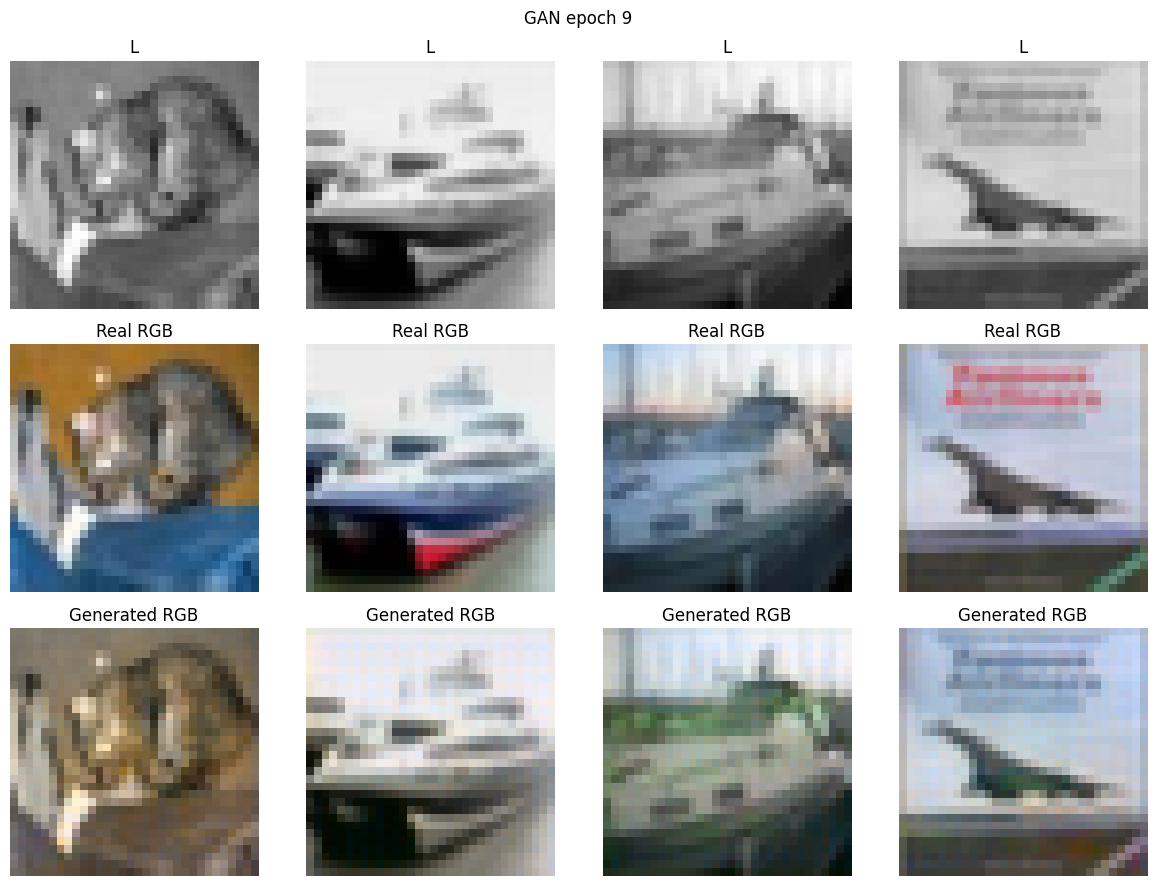

Epoch 10/10 | D: 0.4959 | G: 7.8290 | G_gan: 1.8070 | G_l1: 0.0602


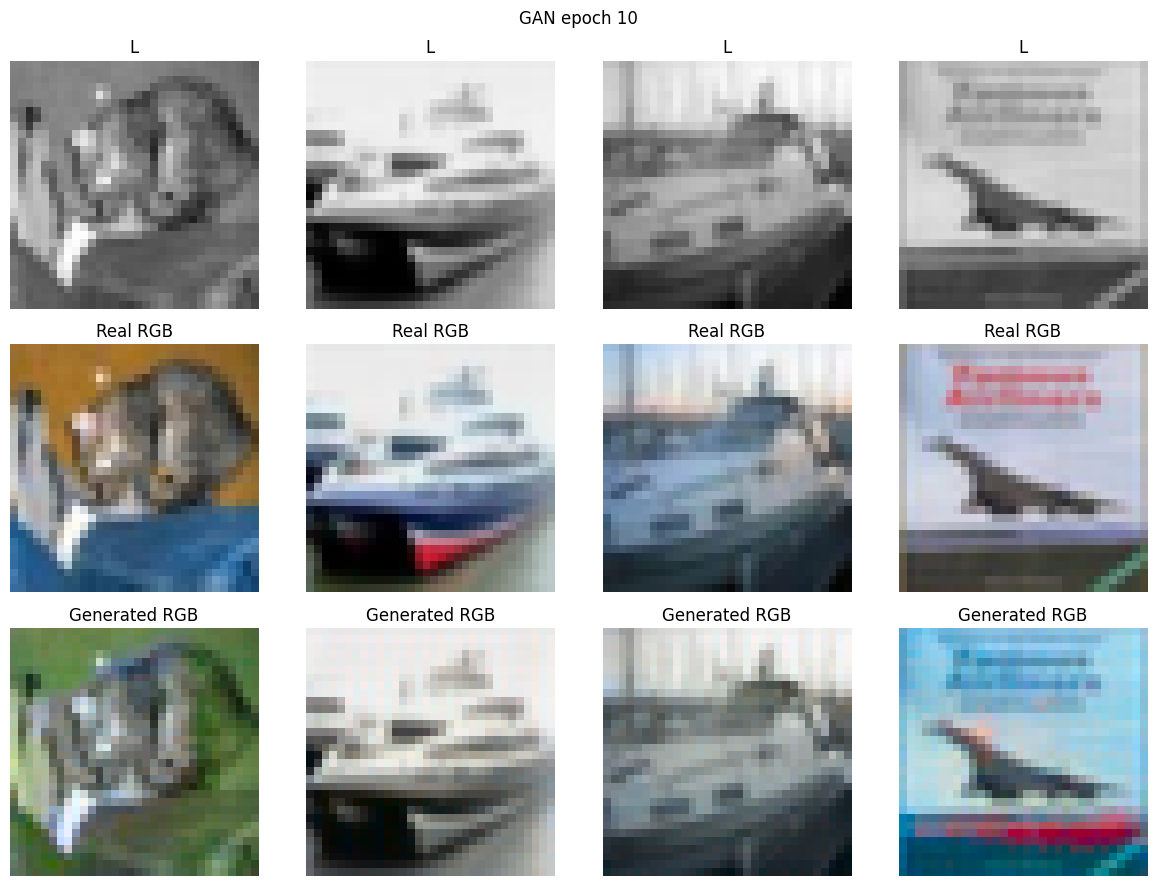

In [13]:
history = {
    "D": [],
    "G": [],
    "G_gan": [],
    "G_l1": [],
}

for epoch in range(num_epochs):
    losses = train_gan_one_epoch(
        generator=G,
        discriminator=D,
        dataloader=trainloader,
        optimizer_G=optimizer_G,
        optimizer_D=optimizer_D,
        criterion_gan=criterion_gan,
        criterion_l1=criterion_l1,
        lambda_l1=lambda_l1,
        device=device,
        real_label_value=0.9,
    )

    for key in history:
        history[key].append(losses[key])

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"D: {losses['D']:.4f} | "
        f"G: {losses['G']:.4f} | "
        f"G_gan: {losses['G_gan']:.4f} | "
        f"G_l1: {losses['G_l1']:.4f}"
    )

    visualize_predictions(
        generator=G,
        dataloader=valloader,
        device=device,
        max_images=4,
        title=f"GAN epoch {epoch + 1}",
    )

 ## Plot GAN Losses

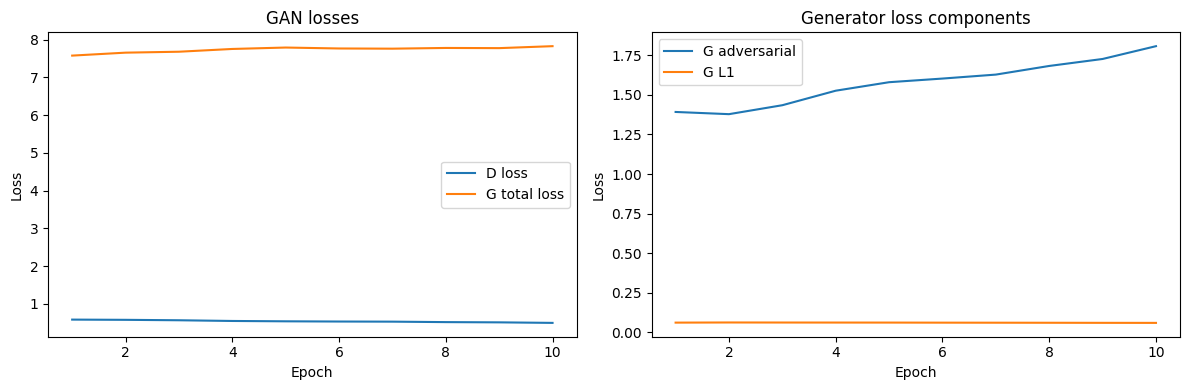

In [14]:
def plot_gan_history(history):
    epochs = np.arange(1, len(history["D"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["D"], label="D loss")
    axes[0].plot(epochs, history["G"], label="G total loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("GAN losses")
    axes[0].legend()

    axes[1].plot(epochs, history["G_gan"], label="G adversarial")
    axes[1].plot(epochs, history["G_l1"], label="G L1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Generator loss components")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_gan_history(history)

 ## Save Checkpoints

In [15]:
checkpoint_dir = "./checkpoints_colorization"
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(G.state_dict(), os.path.join(checkpoint_dir, "generator_cifar_32x32.pth"))
torch.save(D.state_dict(), os.path.join(checkpoint_dir, "discriminator_cifar_32x32.pth"))

print("Saved generator and discriminator.")

Saved generator and discriminator.


 ## Load Checkpoints

In [16]:
G_loaded = UNetGenerator(input_channels=1, output_channels=3).to(device)
G_loaded.load_state_dict(torch.load(os.path.join(checkpoint_dir, "generator_cifar_32x32.pth"), map_location=device))
G_loaded.eval()

UNetGenerator(
  (conv0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(512, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv0): ConvTranspose2d(512, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv1): ConvTranspose2d(1024, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv2): ConvTranspose2d(512, 128, kernel_size=(4

 ## Colorize Real Images

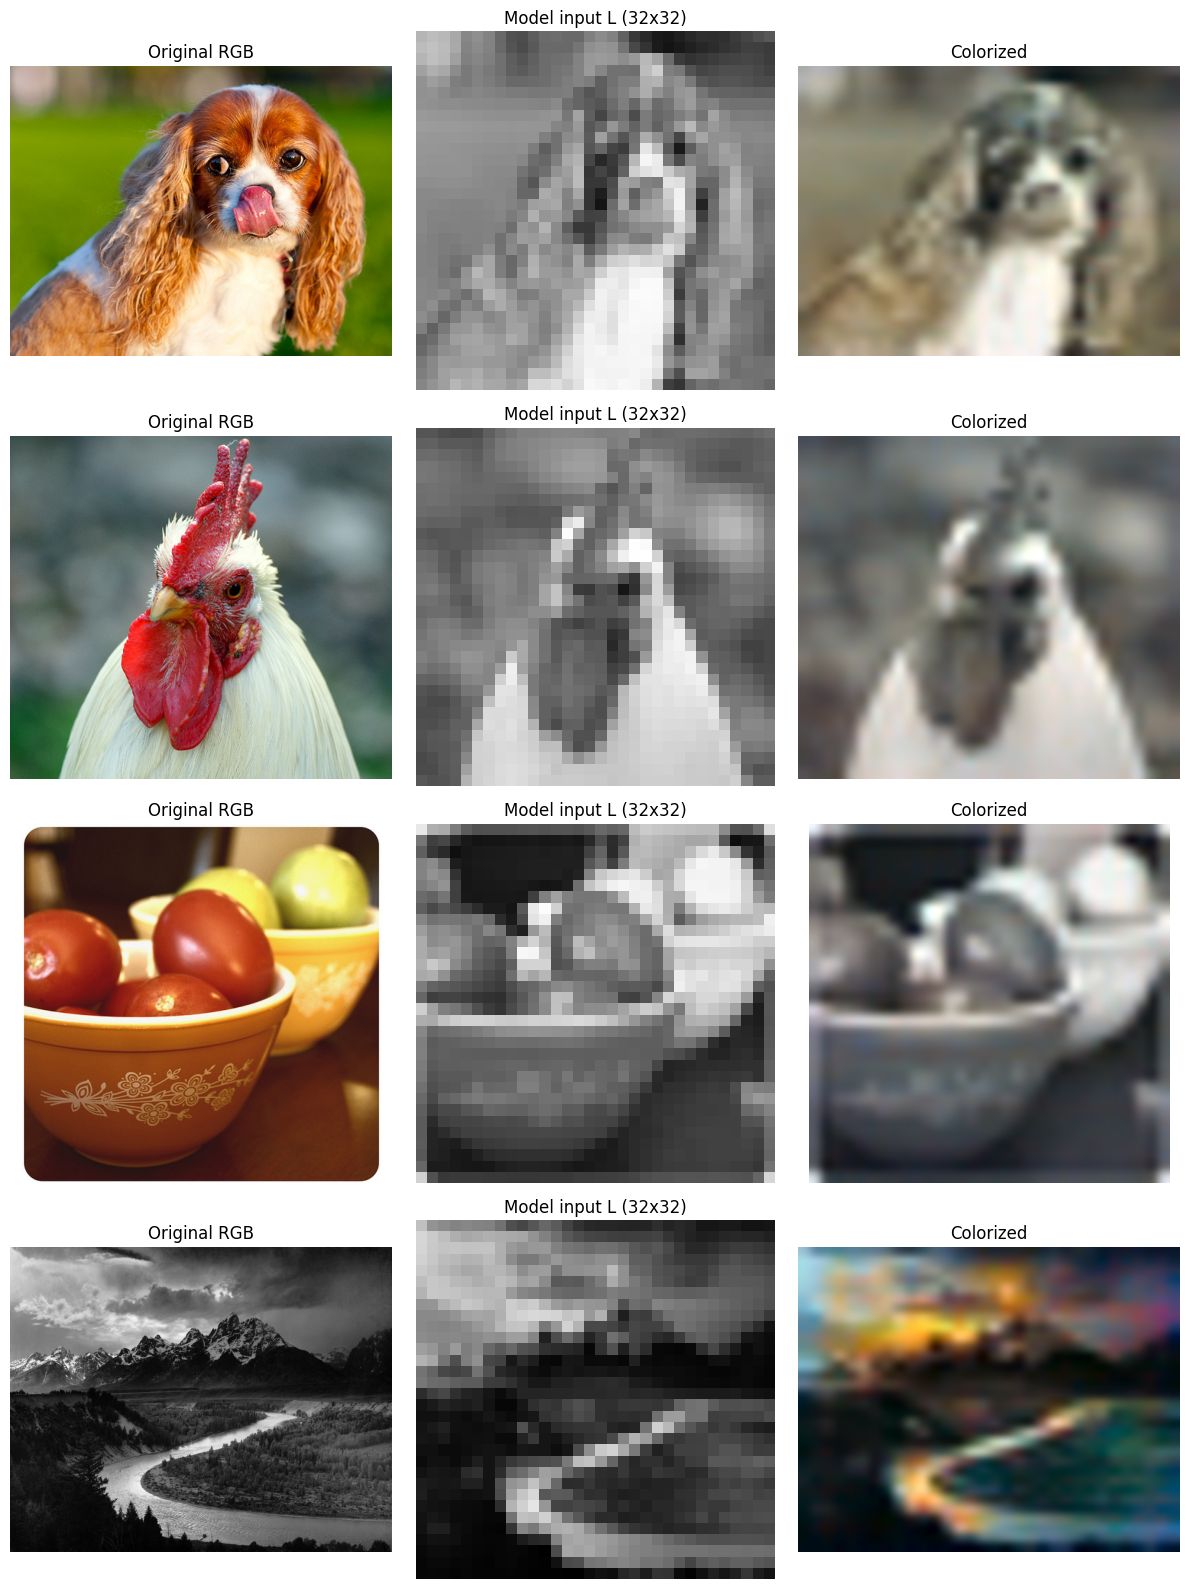

Inference size: 32x32
Saved colorized images:
./colorized_outputs_cifar\ILSVRC2012_val_00041580_colorized.png
./colorized_outputs_cifar\ILSVRC2012_val_00046524_colorized.png
./colorized_outputs_cifar\ILSVRC2012_val_00046834_colorized.png
./colorized_outputs_cifar\ansel_adams_colorized.png


In [19]:
def colorize_image_file(
    generator,
    input_path,
    output_dir="./colorized_outputs",
    inference_size=32,
    device=device,
    use_original_lightness=True,
):
    """
    Colorize one RGB image file with the trained generator.

    The model was trained on image_size, but this U-Net is fully convolutional,
    so other sizes can be tried, but 32 matches this CIFAR training run.
    """
    os.makedirs(output_dir, exist_ok=True)

    pil_img = Image.open(input_path).convert("RGB")
    original_size = pil_img.size
    pil_resized = pil_img.resize((inference_size, inference_size), Image.BICUBIC)

    L_tensor, _ = rgb_to_lab_transform(pil_resized)
    L_batch = L_tensor.unsqueeze(0).to(device)

    generator.eval()
    with torch.no_grad():
        fake_lab = generator(L_batch)

    if use_original_lightness:
        fake_lab = torch.cat([L_batch, fake_lab[:, 1:3, :, :]], dim=1)

    rgb_out = lab_tensors_to_rgb(L_batch, fake_lab)[0]
    rgb_out = np.clip(rgb_out, 0.0, 1.0)

    out_img = Image.fromarray((rgb_out * 255).astype(np.uint8))
    out_img = out_img.resize(original_size, Image.BICUBIC)

    output_path = os.path.join(
        output_dir,
        f"{os.path.splitext(os.path.basename(input_path))[0]}_colorized.png",
    )
    out_img.save(output_path)

    L_display = ((L_tensor.squeeze(0).numpy() + 1.0) * 0.5).clip(0.0, 1.0)

    return pil_img, L_display, out_img, output_path


def colorize_and_show_examples(
    generator,
    image_paths,
    output_dir="./colorized_outputs",
    inference_size=32,
    max_images=4,
):
    image_paths = image_paths[:max_images]
    if len(image_paths) == 0:
        print("No input images found.")
        return []

    results = []
    fig, axes = plt.subplots(len(image_paths), 3, figsize=(12, 4 * len(image_paths)))
    if len(image_paths) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, image_path in enumerate(image_paths):
        original, model_input, colorized, output_path = colorize_image_file(
            generator=generator,
            input_path=image_path,
            output_dir=output_dir,
            inference_size=inference_size,
            device=device,
        )
        results.append(output_path)

        axes[row, 0].imshow(original)
        axes[row, 0].set_title("Original RGB")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(model_input, cmap="gray", vmin=0.0, vmax=1.0)
        axes[row, 1].set_title(f"Model input L ({inference_size}x{inference_size})")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(colorized)
        axes[row, 2].set_title("Colorized")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Inference size: {inference_size}x{inference_size}")
    print("Saved colorized images:")
    for output_path in results:
        print(output_path)

    return results


imgs_dir = os.path.join("..", "imgs")
test_image_paths = sorted(
    glob.glob(os.path.join(imgs_dir, "*.jpg"))
    + glob.glob(os.path.join(imgs_dir, "*.jpeg"))
    + glob.glob(os.path.join(imgs_dir, "*.png"))
)[:4]

colorized_paths = colorize_and_show_examples(
    generator=G_loaded,
    image_paths=test_image_paths,
    output_dir="./colorized_outputs_cifar",
    inference_size=32,
    max_images=4,
)
